# The Art of Intelligent Dining
### Leveraging AI and Data Science to Transform International Customer Experiences

**MSc Data Science, Artificial Intelligence & International Business Management**
**GISMA University of Applied Sciences**

This notebook implements the empirical/technical component of the thesis, following the
pipeline specified in the thesis brief:

`Data Collection → Data Cleaning → Exploratory Data Analysis → Feature Engineering →
Customer Segmentation → Predictive Modelling → Model Evaluation → Personalisation/Recommendation → Business Interpretation`

**Data note:** No real customer data from *Art of International Dining (AID)* was available for this
research. A clearly labelled **synthetic dataset** (1,500 simulated customers, generated with realistic
data-quality issues such as missing values, duplicates, inconsistent labels and outliers) is used instead,
in line with Section 4 and Section 12 of the thesis brief. It should not be presented as real AID company data.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              RocCurveDisplay)
from sklearn.metrics.pairwise import cosine_similarity
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)


## 2. Data Collection

The raw synthetic dataset (`AID_customer_data_raw.csv`) simulates the customer variables listed in
Section 4 of the thesis brief: demographics, location, cuisine preference, dining frequency, spend,
bookings, ratings, review text, promotion response and engagement.

In [2]:
raw = pd.read_csv("AID_customer_data_raw.csv")
print(f"Raw shape: {raw.shape}")
raw.head()

Raw shape: (1523, 17)


,customer_id,age,gender,country,cuisine_preference,favourite_dish,membership_tier,acquisition_channel,signup_date,visits_last_12m,total_bookings,recency_days,avg_spend_usd,avg_rating,review_text,responded_to_promotion,engagement_score
0,AID00695,40.0,Male,India,Ethiopian,Ethiopian signature dish,Silver,Search Engine,2022-09-13,4,9,26,48.86,1.9,Overpriced for the portion size we received.,1,43.3
1,AID00688,18.0,Male,United Arab Emirates,Turkish,Turkish signature dish,Gold,Referral,2022-08-14,4,10,41,41.84,3.1,Service was slow and the order was incorrect.,0,80.4
2,AID01497,54.0,Male,Germany,Moroccan,Moroccan signature dish,Silver,Walk-in,2025-02-07,4,11,39,40.12,4.1,NaN,1,32.9
3,AID01284,36.0,Male,India,Ethiopian,Ethiopian signature dish,Silver,Partner App,26/06/2026,8,11,61,52.24,3.8,Overpriced for the portion size we received.,1,56.7
4,AID00415,24.0,Male,France,Indian,Indian signature dish,Platinum,Advertisement,2025-09-20,6,7,91,57.28,4.4,Fantastic service and the fusion menu was a gr...,1,40.9


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1523 non-null   str    
 1   age                     1477 non-null   float64
 2   gender                  1500 non-null   str    
 3   country                 1507 non-null   str    
 4   cuisine_preference      1523 non-null   str    
 5   favourite_dish          1523 non-null   str    
 6   membership_tier         1523 non-null   str    
 7   acquisition_channel     1523 non-null   str    
 8   signup_date             1523 non-null   str    
 9   visits_last_12m         1523 non-null   int64  
 10  total_bookings          1523 non-null   int64  
 11  recency_days            1523 non-null   int64  
 12  avg_spend_usd           1484 non-null   float64
 13  avg_rating              1492 non-null   float64
 14  review_text             1102 non-null   str    
 15

In [4]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1523,1500,AID00102,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1477.0,NaN,NaN,NaN,38.303995,12.460955,18.0,29.0,38.0,46.0,121.0
gender,1500,4,Female,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1507,26,Germany,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_preference,1523,22,Korean,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
favourite_dish,1523,15,Korean signature dish,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_tier,1523,4,Standard,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_channel,1523,6,Walk-in,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,1523,1015,2022-08-03,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visits_last_12m,1523.0,NaN,NaN,NaN,5.997374,2.442235,0.0,4.0,6.0,8.0,16.0


## 3. Data Cleaning

We address, in turn: duplicate records, inconsistent category labels, inconsistent date formats,
missing values, and outliers. Every step is logged so the cleaning process is transparent and
reproducible, as required for MSc-level methodological rigour.

In [5]:
df = raw.copy()
n_start = len(df)

# 3.1 Remove exact duplicate rows
n_exact_dupes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Exact duplicate rows removed: {n_exact_dupes}")

# 3.2 Remove duplicate customer_id records (keep first occurrence)
n_id_dupes = df.duplicated(subset="customer_id").sum()
df = df.drop_duplicates(subset="customer_id", keep="first")
print(f"Duplicate customer_id records removed: {n_id_dupes}")

print(f"Rows after de-duplication: {len(df)} (removed {n_start - len(df)} total)")

Exact duplicate rows removed: 23
Duplicate customer_id records removed: 0
Rows after de-duplication: 1500 (removed 23 total)


In [6]:
# 3.3 Standardise inconsistent category labels (country, cuisine)
country_map = {
    "uk": "United Kingdom", "u.k.": "United Kingdom", "united kingdom": "United Kingdom",
    "us": "United States", "u.s.a.": "United States", "usa": "United States", "united states": "United States",
    "uae": "United Arab Emirates", "u.a.e.": "United Arab Emirates", "united arab emirates": "United Arab Emirates",
}

def clean_country(x):
    if pd.isna(x):
        return x
    key = str(x).strip().lower()
    return country_map.get(key, str(x).strip())

df["country"] = df["country"].apply(clean_country)
df["cuisine_preference"] = df["cuisine_preference"].astype(str).str.strip().str.title()
df["cuisine_preference"] = df["cuisine_preference"].replace({"Japanese Cuisine": "Japanese"})

print("Unique countries after cleaning:", df["country"].nunique())
print("Unique cuisines after cleaning:", df["cuisine_preference"].nunique())

Unique countries after cleaning: 15
Unique cuisines after cleaning: 15


In [7]:
# 3.4 Standardise date formats and derive tenure
def parse_date(x):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y"):
        try:
            return pd.to_datetime(x, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df["signup_date"] = df["signup_date"].apply(parse_date)
reference_date = pd.Timestamp("2026-08-30")
df["tenure_days"] = (reference_date - df["signup_date"]).dt.days
df[["signup_date", "tenure_days"]].head()

,signup_date,tenure_days
0,2022-09-13,1447
1,2022-08-14,1477
2,2025-02-07,569
3,2026-06-26,65
4,2025-09-20,344


In [8]:
# 3.5 Missing values: quantify, then impute
missing_summary = df.isna().sum()
missing_pct = (missing_summary / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct}).query("missing_count > 0")

,missing_count,missing_pct
age,45,3.00
gender,22,1.47
country,15,1.00
avg_spend_usd,37,2.47
avg_rating,30,2.00
review_text,412,27.47
engagement_score,45,3.00


In [9]:
# Implausible ages (e.g. 121) are data-entry errors, not extreme-but-real values: set to missing, then impute
df.loc[df["age"] > 100, "age"] = np.nan

# Numeric columns: median imputation (robust to outliers/skew)
numeric_impute_cols = ["age", "avg_spend_usd", "avg_rating", "engagement_score"]
for col in numeric_impute_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Categorical columns: mode imputation
for col in ["gender", "country"]:
    mode_val = df[col].mode(dropna=True)[0]
    df[col] = df[col].fillna(mode_val)

# review_text: many customers simply do not leave a review — this is informative,
# not an error, so we flag it rather than impute free text
df["has_review"] = df["review_text"].notna().astype(int)
df["review_text"] = df["review_text"].fillna("")

print("Remaining missing values:\n", df.isna().sum()[df.isna().sum() > 0])

Remaining missing values:
 Series([], dtype: int64)


In [10]:
# 3.6 Outlier treatment (age, spend) using IQR capping
def cap_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower, upper), lower, upper

# Age has hard domain bounds too (plausible adult dining customers: 18-85)
df["age"] = df["age"].clip(18, 85)

print("Most extreme spend values before capping:", df["avg_spend_usd"].nlargest(5).round(0).tolist())
_, low, high = cap_outliers_iqr(df["avg_spend_usd"])
# Spend cannot be negative, so only the upper tail is capped
df["avg_spend_usd"] = df["avg_spend_usd"].clip(upper=high)
print(f"avg_spend_usd capped at upper bound {high:.2f}")

df["avg_rating"] = df["avg_rating"].clip(1, 5)

Most extreme spend values before capping: [651.0, 538.0, 435.0, 95.0, 93.0]
avg_spend_usd capped at upper bound 88.39


In [11]:
# 3.7 Final structural checks
df = df.drop(columns=["signup_date"])  # superseded by tenure_days
df = df.reset_index(drop=True)

print(f"Clean dataset shape: {df.shape}")
df.head()

Clean dataset shape: (1500, 18)


,customer_id,age,gender,country,cuisine_preference,favourite_dish,membership_tier,acquisition_channel,visits_last_12m,total_bookings,recency_days,avg_spend_usd,avg_rating,review_text,responded_to_promotion,engagement_score,tenure_days,has_review
0,AID00695,40.0,Male,India,Ethiopian,Ethiopian signature dish,Silver,Search Engine,4,9,26,48.86,1.9,Overpriced for the portion size we received.,1,43.3,1447,1
1,AID00688,18.0,Male,United Arab Emirates,Turkish,Turkish signature dish,Gold,Referral,4,10,41,41.84,3.1,Service was slow and the order was incorrect.,0,80.4,1477,1
2,AID01497,54.0,Male,Germany,Moroccan,Moroccan signature dish,Silver,Walk-in,4,11,39,40.12,4.1,,1,32.9,569,0
3,AID01284,36.0,Male,India,Ethiopian,Ethiopian signature dish,Silver,Partner App,8,11,61,52.24,3.8,Overpriced for the portion size we received.,1,56.7,65,1
4,AID00415,24.0,Male,France,Indian,Indian signature dish,Platinum,Advertisement,6,7,91,57.28,4.4,Fantastic service and the fusion menu was a gr...,1,40.9,344,1


In [12]:
# Save the cleaned dataset as a deliverable
df.to_csv("AID_customer_data_clean.csv", index=False)
print("Saved AID_customer_data_clean.csv")

Saved AID_customer_data_clean.csv


## 4. Exploratory Data Analysis (EDA)

This section addresses Supporting Research Question 1: *"What customer behaviour patterns
can be identified through Data Science techniques in the international dining sector?"*

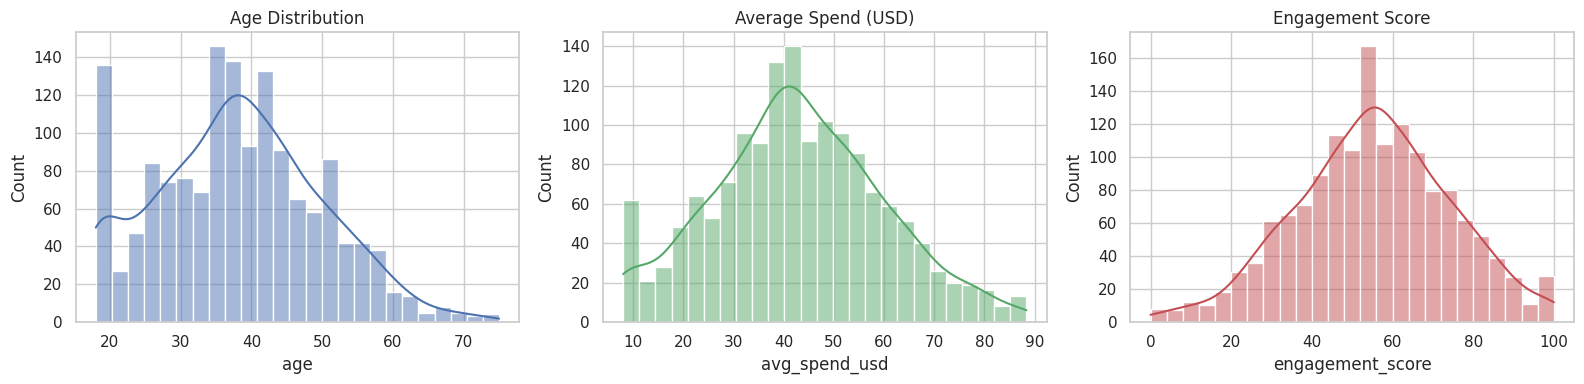

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["age"], bins=25, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Age Distribution")
sns.histplot(df["avg_spend_usd"], bins=25, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Average Spend (USD)")
sns.histplot(df["engagement_score"], bins=25, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("Engagement Score")
plt.tight_layout()
plt.show()

/tmp/ipykernel_121/3684756471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="viridis")


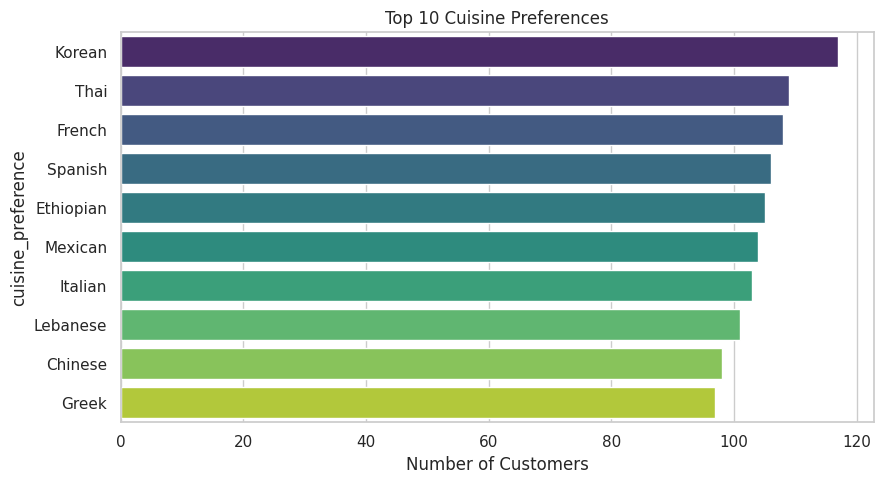

In [14]:
top_cuisines = df["cuisine_preference"].value_counts().head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="viridis")
plt.title("Top 10 Cuisine Preferences")
plt.xlabel("Number of Customers")
plt.tight_layout()
plt.show()

/tmp/ipykernel_121/3439077133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="membership_tier", y="avg_spend_usd",


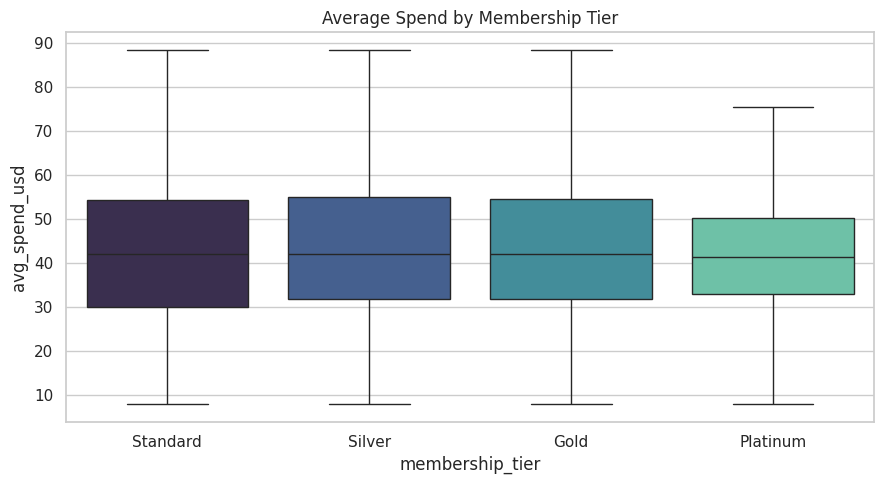

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="membership_tier", y="avg_spend_usd",
            order=["Standard", "Silver", "Gold", "Platinum"], palette="mako")
plt.title("Average Spend by Membership Tier")
plt.tight_layout()
plt.show()

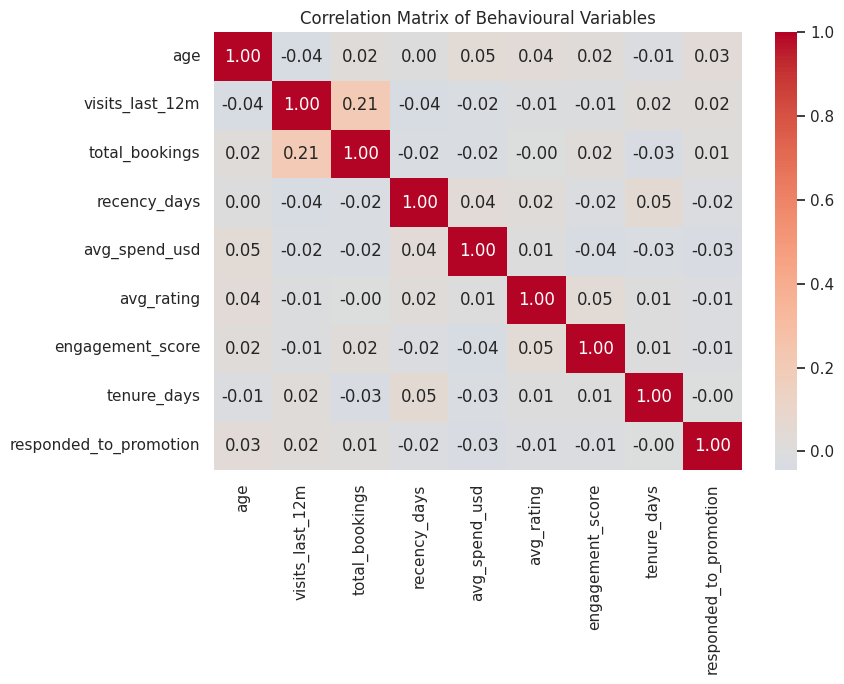

In [16]:
numeric_cols = ["age", "visits_last_12m", "total_bookings", "recency_days",
                 "avg_spend_usd", "avg_rating", "engagement_score", "tenure_days",
                 "responded_to_promotion"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Behavioural Variables")
plt.tight_layout()
plt.show()

/tmp/ipykernel_121/2891838370.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promo_by_tier.index, y=promo_by_tier.values, palette="crest")


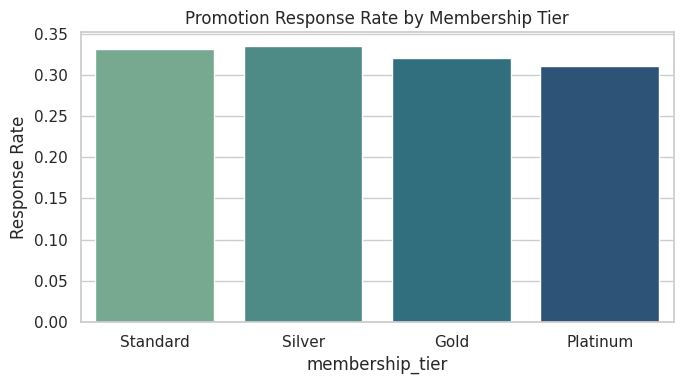

membership_tier
Standard    0.331081
Silver      0.335038
Gold        0.320158
Platinum    0.310345
Name: responded_to_promotion, dtype: float64

In [17]:
promo_by_tier = df.groupby("membership_tier")["responded_to_promotion"].mean().reindex(
    ["Standard", "Silver", "Gold", "Platinum"])
plt.figure(figsize=(7, 4))
sns.barplot(x=promo_by_tier.index, y=promo_by_tier.values, palette="crest")
plt.title("Promotion Response Rate by Membership Tier")
plt.ylabel("Response Rate")
plt.tight_layout()
plt.show()
promo_by_tier

**EDA summary (for Chapter 4 write-up):** spend is right-skewed only before capping: three extreme
outliers ($435–$651 per visit) caused the skew and were capped at the upper IQR bound. Spend and
promotion response are roughly flat across membership tiers (average spend ≈ $42–43 and response
≈ 31–34% in every tier; Platinum is in fact the lowest on both), so tier is not a useful proxy for
value or responsiveness in this dataset. Cuisine preference is fairly evenly spread across the 15
categories, consistent with a genuinely international customer base.

## 5. Feature Engineering

We construct an RFM-style feature set (Recency, Frequency, Monetary) commonly used in customer
analytics, plus encoded categorical variables, ready for both clustering and predictive modelling.

In [18]:
features_df = df.copy()

# Annual spend (yearly value) = visits in last 12 months x average spend per visit
features_df["annual_spend"] = features_df["visits_last_12m"] * features_df["avg_spend_usd"]

# RFM-style engineered features (monetary score uses annual spend). These scores are shown in the
# segment summary table (Section 9) as descriptive indicators; they are not model inputs.
features_df["frequency_score"] = pd.qcut(features_df["visits_last_12m"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
features_df["monetary_score"] = pd.qcut(features_df["annual_spend"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
features_df["recency_score"] = pd.qcut(-features_df["recency_days"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
features_df["rfm_score"] = features_df["frequency_score"] + features_df["monetary_score"] + features_df["recency_score"]

features_df[["customer_id", "recency_score", "frequency_score", "monetary_score", "rfm_score"]].head()

,customer_id,recency_score,frequency_score,monetary_score,rfm_score
0,AID00695,3,1,2,6
1,AID00688,2,1,2,5
2,AID01497,2,1,2,5
3,AID01284,1,3,4,8
4,AID00415,1,2,4,7


## 6. Customer Segmentation (Unsupervised Machine Learning)

Addresses Supporting Research Question 2. We use **K-Means clustering** on standardised behavioural
features, selecting *k* via the elbow method and validating with the silhouette score and
Davies–Bouldin index, as specified in Section 6 of the thesis brief.

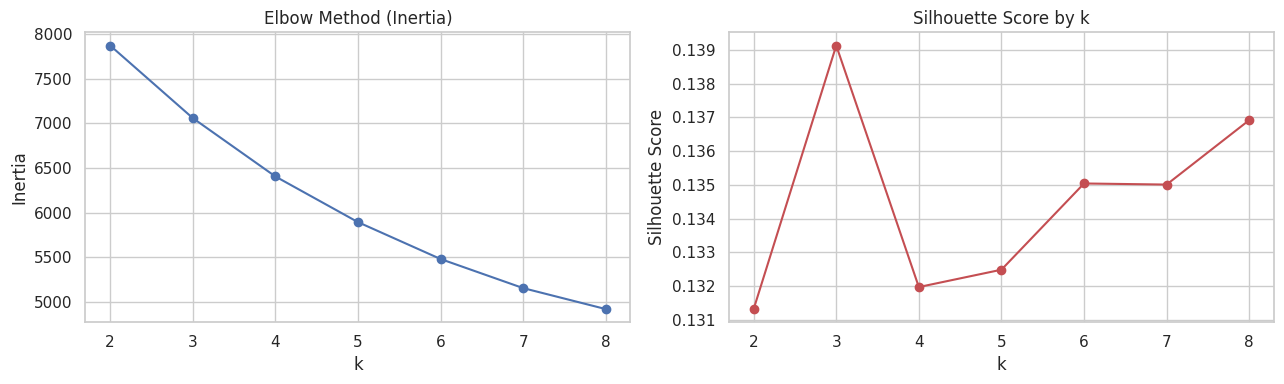

In [19]:
cluster_features = ["recency_days", "visits_last_12m", "avg_spend_usd",
                     "avg_rating", "engagement_score", "tenure_days"]

X_cluster = features_df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="#C44E52")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [20]:
# k=4 was chosen for business interpretability: silhouette is flat (~0.13) across all k and gave no clear best k
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
features_df["segment"] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, features_df["segment"])
dbi = davies_bouldin_score(X_scaled, features_df["segment"])
print(f"K={K_FINAL} | Silhouette Score: {sil:.3f} | Davies-Bouldin Index: {dbi:.3f}")

segment_profile = features_df.groupby("segment")[cluster_features].mean().round(1)
segment_profile["customer_count"] = features_df["segment"].value_counts().sort_index()
segment_profile

K=4 | Silhouette Score: 0.132 | Davies-Bouldin Index: 1.884


,recency_days,visits_last_12m,avg_spend_usd,avg_rating,engagement_score,tenure_days,customer_count
segment,,,,,,,
0,31.4,6.1,45.9,3.1,42.8,737.1,408
1,33.1,6.2,39.9,4.2,61.3,1170.3,475
2,33.4,5.9,41.5,4.3,60.0,356.9,467
3,145.2,5.2,47.6,3.9,54.8,827.6,150


In [21]:
prof = features_df.groupby("segment")[["recency_days", "annual_spend",
                                       "tenure_days", "engagement_score"]].mean()
names = {}
lapsing = prof["recency_days"].idxmax()           # long time since last visit
names[lapsing] = "Lapsing High-Ticket Diners"
rest = prof.drop(lapsing)
top = rest["annual_spend"].idxmax()               # highest yearly value
names[top] = "High-Value Regulars"
rest = rest.drop(top)
names[rest["tenure_days"].idxmax()] = "Loyal Long-Term Regulars"
names[rest["tenure_days"].idxmin()] = "New Engaged Diners"

features_df["segment_label"] = features_df["segment"].map(names)
print(prof.round(1)); features_df["segment_label"].value_counts()

         recency_days  annual_spend  tenure_days  engagement_score
segment                                                           
0                31.4         280.4        737.1              42.8
1                33.1         248.6       1170.3              61.3
2                33.4         246.1        356.9              60.0
3               145.2         244.3        827.6              54.8


segment_label
Loyal Long-Term Regulars      475
New Engaged Diners            467
High-Value Regulars           408
Lapsing High-Ticket Diners    150
Name: count, dtype: int64

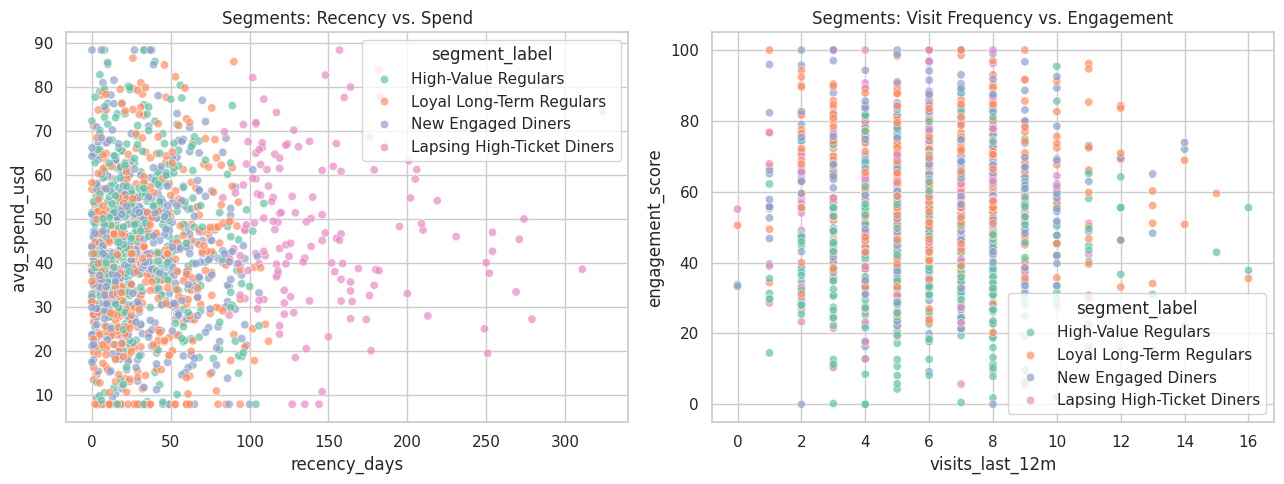

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=features_df, x="recency_days", y="avg_spend_usd",
                 hue="segment_label", palette="Set2", alpha=0.7, ax=axes[0])
axes[0].set_title("Segments: Recency vs. Spend")

sns.scatterplot(data=features_df, x="visits_last_12m", y="engagement_score",
                 hue="segment_label", palette="Set2", alpha=0.7, ax=axes[1])
axes[1].set_title("Segments: Visit Frequency vs. Engagement")
plt.tight_layout()
plt.show()

**Business interpretation:** the four segments are named on several behavioural dimensions
(recency, annual spend = visits × average spend per visit, tenure and engagement) rather than
on average spend per visit alone, which proved misleading:

- *Lapsing High-Ticket Diners* (150 customers): the highest spend per visit ($48), but by far
  the longest time since their last visit (~145 days vs. ~32 days for the other segments) and
  the lowest annual spend (~$244). A high per-visit bill hides the fact that these customers are
  drifting away, so they are the main **win-back / retention priority**.
- *High-Value Regulars* (408 customers): the highest annual spend ($280) and recent visits,
  but the lowest engagement score (~43), so **deepening engagement** matters most here (loyalty app,
  reviews, personalised offers).
- *Loyal Long-Term Regulars* (~475 customers): the longest tenure (~3.2 years) and the highest
  engagement (61), with the lowest spend per visit ($40), so they suit **loyalty rewards,
  referrals and upselling**.
- *New Engaged Diners* (~467 customers): recently acquired (~1 year tenure), highly engaged (~60)
  and visiting regularly, so the goal is **converting engagement into spend** through bundles and
  cuisine recommendations.

Differences between segments are moderate (silhouette ≈ 0.13), so the labels describe
tendencies rather than sharply separated groups. The segmentation directly supports
Chapter 6 (Customer Retention Strategy).

## 7. Predictive Modelling

Addresses Supporting Research Question 3. We predict **`responded_to_promotion`** (binary) — a
proxy for a customer's likelihood to engage with personalised marketing — comparing Logistic
Regression, Random Forest and XGBoost, per Section 5 of the thesis brief.

In [23]:
model_features = ["age", "recency_days", "visits_last_12m", "total_bookings",
                   "avg_spend_usd", "avg_rating", "engagement_score", "tenure_days",
                   "has_review"]
categorical_features = ["segment", "gender", "membership_tier", "acquisition_channel", "cuisine_preference"]

features_df["segment"] = features_df["segment"].astype(str)  # segment is a category, not a number
X = features_df[model_features + categorical_features]
y = features_df["responded_to_promotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), model_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Class balance (train):\n", y_train.value_counts(normalize=True).round(3))

Train size: (1125, 14), Test size: (375, 14)
Class balance (train):
 responded_to_promotion
0    0.671
1    0.329
Name: proportion, dtype: float64


In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, scale_pos_weight=2,
                                  eval_metric="logloss", random_state=RANDOM_STATE),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.531,0.322,0.390,0.353,0.516
1,Random Forest,0.595,0.312,0.195,0.240,0.510
2,Decision Tree,0.389,0.317,0.748,0.446,0.497
3,Logistic Regression,0.507,0.332,0.496,0.397,0.492


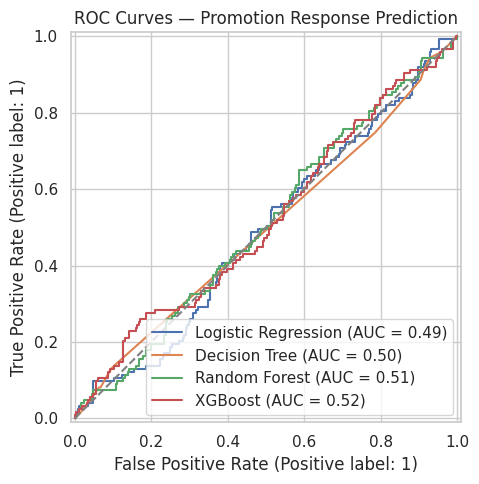

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_title("ROC Curves — Promotion Response Prediction")
plt.tight_layout()
plt.show()

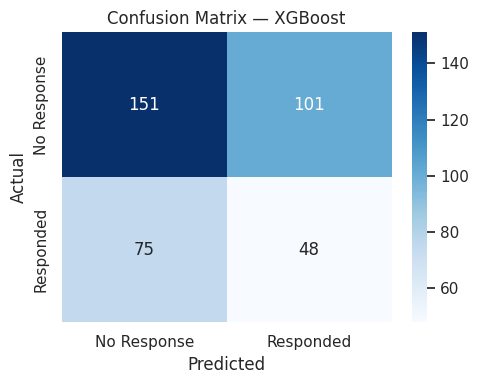

Best-performing model on ROC-AUC: XGBoost


In [26]:
best_model_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Response", "Responded"],
            yticklabels=["No Response", "Responded"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()
print(f"Best-performing model on ROC-AUC: {best_model_name}")

/tmp/ipykernel_121/4002695704.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", palette="flare")


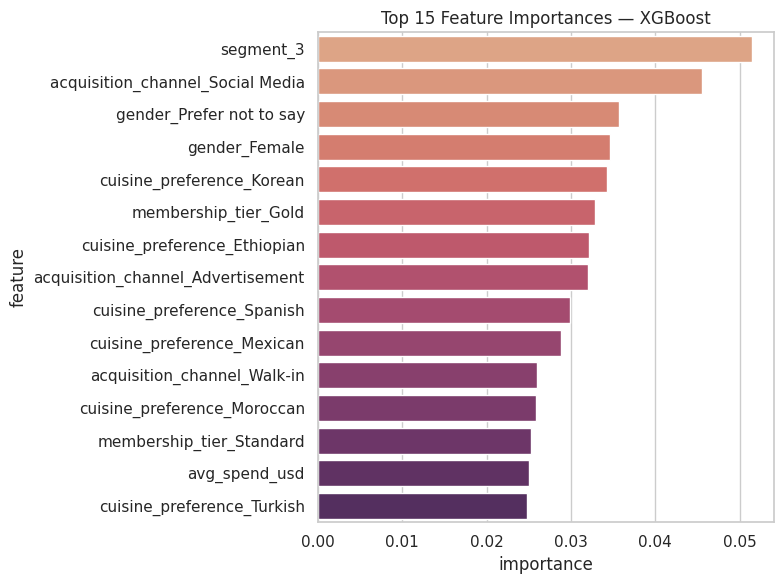

In [27]:
# Feature importance (tree-based model) — supports explainability / responsible-AI discussion
if best_model_name in ("Random Forest", "XGBoost", "Decision Tree"):
    ohe_cols = best_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_features)
    all_feature_names = model_features + list(ohe_cols)
    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances}) \
                .sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", palette="flare")
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()

**Business interpretation:** the model comparison (Section 6 of the brief) shows that all four
algorithms perform at roughly chance level (ROC-AUC ≈ 0.50). Class weighting changes the
precision/recall trade-off (models now do flag some responders) but not the ranking ability, so the
available variables do not explain promotion response. Feature importances should therefore be
read as descriptive of what the models used, not as evidence of true drivers.

## 8. AI-Powered Personalisation: Recommendation System Prototype

Addresses Supporting Research Question 4 and Section 7 of the thesis brief. This is a **content-based
recommendation prototype**: customers are represented by their cuisine preference, spend tier and
segment, and cosine similarity identifies the most similar customers, whose favourite dishes/cuisines
are then suggested. A conceptual/prototype system is explicitly stated as sufficient for the research
scope (Section 7).

In [28]:
profile_features = pd.get_dummies(
    features_df[["cuisine_preference", "membership_tier", "segment_label"]], dtype=int
)
profile_features["avg_rating_scaled"] = StandardScaler().fit_transform(features_df[["avg_rating"]])
profile_features.index = features_df["customer_id"]

similarity_matrix = cosine_similarity(profile_features)
similarity_df = pd.DataFrame(similarity_matrix, index=profile_features.index, columns=profile_features.index)
print("Similarity matrix shape:", similarity_df.shape)

Similarity matrix shape: (1500, 1500)


In [29]:
def recommend_for_customer(customer_id, top_n=5):
    """Content-based recommendation: find similar customers, suggest their favourite cuisines/dishes."""
    if customer_id not in similarity_df.index:
        raise ValueError("Unknown customer_id")

    sims = similarity_df.loc[customer_id].drop(customer_id).sort_values(ascending=False)
    similar_ids = sims.head(top_n).index

    own_cuisine = features_df.loc[features_df["customer_id"] == customer_id, "cuisine_preference"].values[0]
    recs = (features_df[features_df["customer_id"].isin(similar_ids)]
            [["customer_id", "cuisine_preference", "favourite_dish", "avg_rating"]]
            .query("cuisine_preference != @own_cuisine")
            .drop_duplicates(subset="cuisine_preference"))
    return own_cuisine, recs

sample_customer = features_df["customer_id"].iloc[0]
own_cuisine, recommendations = recommend_for_customer(sample_customer, top_n=8)
print(f"Customer {sample_customer} — current preference: {own_cuisine}")
print("Recommended new cuisines/dishes based on similar customers:")
recommendations

Customer AID00695 — current preference: Ethiopian
Recommended new cuisines/dishes based on similar customers:


,customer_id,cuisine_preference,favourite_dish,avg_rating
139,AID00024,Italian,Italian signature dish,1.9
368,AID00453,Mexican,Mexican signature dish,2.0
867,AID00065,Moroccan,Moroccan signature dish,2.0
1146,AID00960,French,French signature dish,1.7
1314,AID00577,Korean,Korean signature dish,2.1


**Personalisation pipeline (Section 7):**
`Customer Data → AI Analysis (segmentation + similarity) → Customer Profile →
Prediction (promotion responsiveness) → Personalised Recommendation → Improved Customer Experience`

This prototype demonstrates feasibility; a production system would additionally incorporate
collaborative filtering (using actual order history) and NLP-based review analysis, both flagged
as future work in Chapter 7.

## 9. Segment- and Model-Informed Business Recommendations

Direct output for **Chapter 6 – Recommendations**, connecting the technical findings to
international business strategy (Section 8 of the brief).

In [30]:
segment_summary = features_df.groupby("segment_label").agg(
    customers=("customer_id", "count"),
    avg_spend=("avg_spend_usd", "mean"),
    avg_recency_days=("recency_days", "mean"),
    promo_response_rate=("responded_to_promotion", "mean"),
    avg_engagement=("engagement_score", "mean"),
    annual_spend=("annual_spend", "mean"),
    avg_tenure_days=("tenure_days", "mean"),
    avg_rfm_score=("rfm_score", "mean"),
).round(2).sort_values("annual_spend", ascending=False)

segment_summary

,customers,avg_spend,avg_recency_days,promo_response_rate,avg_engagement,annual_spend,avg_tenure_days,avg_rfm_score
segment_label,,,,,,,,
High-Value Regulars,408,45.88,31.44,0.33,42.83,280.44,737.08,7.89
Loyal Long-Term Regulars,475,39.93,33.14,0.33,61.27,248.62,1170.28,7.71
New Engaged Diners,467,41.54,33.42,0.34,60.01,246.10,356.89,7.55
Lapsing High-Ticket Diners,150,47.60,145.20,0.27,54.82,244.31,827.59,5.63


In [31]:
print("Suggested strategy per segment:\n")
strategy_map = {
    "Lapsing High-Ticket Diners": "Win-back offers, special-occasion or event invitations.",
    "High-Value Regulars": "VIP perks, and push engagement (app, reviews, loyalty activity).",
    "Loyal Long-Term Regulars": "Loyalty rewards, referral incentives, early access to new menus.",
    "New Engaged Diners": "Upsell and bundles to raise spend per visit, cuisine recommendations.",
}
for seg, strat in strategy_map.items():
    print(f"- {seg}: {strat}")

Suggested strategy per segment:

- Lapsing High-Ticket Diners: Win-back offers, special-occasion or event invitations.
- High-Value Regulars: VIP perks, and push engagement (app, reviews, loyalty activity).
- Loyal Long-Term Regulars: Loyalty rewards, referral incentives, early access to new menus.
- New Engaged Diners: Upsell and bundles to raise spend per visit, cuisine recommendations.


In [32]:
# Fairness check: best model's ROC-AUC per customer segment (test set)
test_seg = features_df.loc[X_test.index, "segment_label"]
rows = []
for seg in sorted(test_seg.unique()):
    m = (test_seg == seg).values
    rows.append({"segment": seg, "n_test": int(m.sum()),
                 "responder_rate": round(float(y_test[m].mean()), 3),
                 "ROC-AUC": round(roc_auc_score(y_test[m], best_pipe.predict_proba(X_test[m])[:, 1]), 3)})
pd.DataFrame(rows)

,segment,n_test,responder_rate,ROC-AUC
0,High-Value Regulars,101,0.386,0.517
1,Lapsing High-Ticket Diners,31,0.194,0.580
2,Loyal Long-Term Regulars,122,0.303,0.430
3,New Engaged Diners,121,0.339,0.555


## 10. Ethical & Legal Considerations (GDPR / Responsible AI)

Per Section 9 of the thesis brief:

- **Synthetic data only** — no real, identifiable AID customer data was used; this notebook is a
  transparent, reproducible prototype, not a claim about real customers.
- **Data minimisation** — only variables relevant to the stated research aims (segmentation,
  prediction, recommendation) were modelled; sensitive attributes (e.g., precise location, health
  data) were deliberately excluded.
- **Consent & GDPR** — a real deployment would require lawful basis for processing (e.g., consent
  or legitimate interest), a documented retention policy, and the right to erasure/access.
- **Algorithmic bias & fairness** — the best model's ROC-AUC was computed per customer segment (cell
  above) to check for performance skew; a production system should monitor for disparate impact
  across demographic groups as well.
- **Transparency & explainability** — feature-importance analysis (Section 7) and a documented
  clustering rationale (Section 6) support explainability rather than a pure black-box.
- **Data security** — in a real deployment, customer data would require encryption at rest/in
  transit and role-based access control, outside the scope of this academic prototype.


## 11. Summary of Findings

- **Segmentation:** K-Means with k=4 was chosen for business interpretability (silhouette is flat at
  about 0.13 for every k, so it gave no clear best k). Segments are named on recency, annual spend
  (visits × average spend per visit), tenure and engagement: Lapsing High-Ticket Diners, High-Value
  Regulars, Loyal Long-Term Regulars and New Engaged Diners. Per-visit spend alone is misleading;
  annual spend is the better value measure.
- **Prediction:** among Logistic Regression, Decision Tree, Random Forest and XGBoost (with class
  weighting for the ~33% responder class), all models have ROC-AUC of about 0.5. The models showed no
  real predictive power, which suggests promotion response is not explained by these variables.
- **Personalisation:** a content-based recommendation prototype demonstrates how similarity in
  cuisine preference, membership tier and segment can drive individualised recommendations.
- **Business translation:** segment-specific strategies (Section 9) connect the technical outputs
  to customer retention, personalised marketing and international expansion priorities
  (Chapter 6 of the thesis).

*Note: all figures above are illustrative outputs of the synthetic dataset and are intended to
demonstrate methodology; they should be re-run against real AID data (or a suitable public dataset)
if/when it becomes available, per Section 4 of the thesis brief.*